## Break Through Tech Supply Chain ML Model


In [2]:
# Import the dat
import pandas as pd
import zipfile

with zipfile.ZipFile('C:\\Users\\ngair\\Downloads\\Global Supply Chain Disruption Dataset (2015–2026) (1).zip', 'r') as zip_ref:
    zip_ref.extractall('C:\\Users\\ngair\\Downloads\\Extracted_Data')
extracted_dir = Path(r'C:\Users\ngair\Downloads\Extracted_Data')
csv_files = list(extracted_dir.rglob('*.csv'))

if not csv_files:
    raise FileNotFoundError(f'No CSV files found in {extracted_dir}')

data = pd.read_csv(csv_files[0])

In [3]:
data

,date,oil_price,natural_gas_price,steel_price,wheat_price,copper_price,commodity_stress_index
0,2015-01-04,62.483571,2.505198,500.313218,186.331236,6674.454842,19.2000
1,2015-01-11,59.308678,2.937107,618.702828,203.882599,6752.376841,35.0500
2,2015-01-18,63.238443,3.027862,661.383450,239.297033,7884.728328,74.2200
3,2015-01-25,67.615149,3.547096,539.517949,252.311656,7373.403874,68.5900
4,2015-02-01,58.829233,2.153768,683.628619,195.313023,6594.677690,28.9800
...,...,...,...,...,...,...,...
621,2026-11-29,99.771747,3.661019,638.983027,226.801026,7221.895946,69.6875
622,2026-12-06,111.056196,4.363650,665.515437,231.412260,6427.193174,72.7625
623,2026-12-13,106.763360,3.110873,669.784191,239.363693,7395.490697,82.6625
624,2026-12-20,108.745493,4.431616,571.891599,213.373832,7021.804157,62.2250


In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, mean_absolute_error, r2_score)

ops = pd.read_csv("C:\\Users\\ngair\\Downloads\\weekly_route_operations.csv", parse_dates=["date"])
routes = pd.read_csv("C:\\Users\\ngair\\Downloads\\trade_routes.csv")
countries = pd.read_csv("C:\\Users\\ngair\\Downloads\\country_metadata.csv")
commodity = pd.read_csv("C:\\Users\\ngair\\Downloads\\commodity_market.csv", parse_dates=["date"])
events = pd.read_csv("C:\\Users\\ngair\\Downloads\\geopolitical_events.csv", parse_dates=["date"])
events["date"] = pd.to_datetime(events["date"], format="mixed")  # 3 "MAJOR" rows lack a time part

# ---------- geopolitical events -> weekly features per event region ----------
# Map World Bank-style country regions to the coarser event regions.
COUNTRY_TO_EVENT_REGION = {
    "East Asia & Pacific": "Asia",
    "South Asia": "Asia",
    "North America": "North America",
    "Europe & Central Asia": "Europe",
    "Latin America & Caribbean": "South America",
}
countries["event_region"] = countries["region"].map(COUNTRY_TO_EVENT_REGION)

events["end"] = events["date"] + pd.to_timedelta(events["duration_days"], unit="D")
weeks = pd.DataFrame({"week_start": np.sort(ops["date"].unique())})
weeks["week_end"] = weeks["week_start"] + pd.Timedelta(days=6)


def active_event_stats(ev: pd.DataFrame) -> pd.DataFrame:
    """For each week, stats over events active at any point during that week."""
    rows = []
    starts, ends = ev["date"].values, ev["end"].values
    sev, risk = ev["severity"].values, ev["risk_increase"].values
    new_mask_src = ev["date"].values
    for ws, we in zip(weeks["week_start"].values, weeks["week_end"].values):
        active = (starts <= we) & (ends >= ws)
        new = (new_mask_src >= ws) & (new_mask_src <= we)
        rows.append({
            "active_events": active.sum(),
            "new_events": new.sum(),
            "max_severity": sev[active].max() if active.any() else 0,
            "mean_severity": sev[active].mean() if active.any() else 0,
            "total_risk_increase": risk[active].sum(),
        })
    return pd.concat([weeks[["week_start"]].reset_index(drop=True), pd.DataFrame(rows)], axis=1)


regional = {}
for region in ["Asia", "Europe", "North America", "South America", "Middle East", "Africa"]:
    # "Global" events count toward every region
    ev = events[events["affected_region"].isin([region, "Global"])]
    regional[region] = active_event_stats(ev).assign(event_region=region)
regional = pd.concat(regional.values(), ignore_index=True)

# Worldwide event pressure (all regions) as extra context
global_ev = active_event_stats(events).add_prefix("global_").rename(
    columns={"global_week_start": "week_start"})

# ---------- merge ----------
df = ops.merge(routes, on="route_id", how="left")

country_cols = ["country", "region", "event_region", "income_group", "population", "gdp_per_capita",
                "trade_dependency_score", "port_capacity_index", "logistics_performance_index"]
for side in ["origin", "destination"]:
    c = countries[country_cols].add_prefix(f"{side}_")
    df = df.merge(c, left_on=f"{side}_country", right_on=f"{side}_country", how="left")
    r = regional.rename(columns={"week_start": "date", "event_region": f"{side}_event_region"})
    r = r.rename(columns={k: f"{side}_region_{k}" for k in
                          ["active_events", "new_events", "max_severity", "mean_severity",
                           "total_risk_increase"]})
    df = df.merge(r, on=["date", f"{side}_event_region"], how="left")

df = df.merge(commodity, on="date", how="left")
df = df.merge(global_ev.rename(columns={"week_start": "date"}), on="date", how="left")

df["same_region"] = (df["origin_event_region"] == df["destination_event_region"]).astype(int)
df["year"] = df["date"].dt.year
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["month"] = df["date"].dt.month

assert len(df) == len(ops), "merge changed row count"
print(f"Merged table: {df.shape[0]:,} rows x {df.shape[1]} columns -> output/merged_supply_chain.csv")


Merged table: 31,300 rows x 60 columns -> output/merged_supply_chain.csv


In [6]:
## ---------- features ----------
TARGET = "route_status"
DROP = ["date", "route_id", TARGET, "shipping_delay_days",  # label / leakage
        "origin_country", "destination_country"]             # high-card IDs; country attrs kept
X = df.drop(columns=DROP)
X = pd.get_dummies(X, columns=X.select_dtypes("object").columns.tolist(), drop_first=False)
y = df[TARGET]

# Time-based split: train on weeks before 2024, test on 2024-2026 (no future leakage)
train = df["date"] < "2024-01-01"
X_tr, X_te, y_tr, y_te = X[train], X[~train], y[train], y[~train]
print(f"Train: {train.sum():,} rows (2015-2023)  |  Test: {(~train).sum():,} rows (2024-2026)")


Train: 23,500 rows (2015-2023)  |  Test: 7,800 rows (2024-2026)


In [7]:

# ---------- classifier ----------
# Larger leaves + per-tree class balancing so the rare "Disrupted" class (~3%) gets predicted at all
clf = RandomForestClassifier(n_estimators=400, min_samples_leaf=30, max_features=0.5,
                             class_weight="balanced_subsample",
                             n_jobs=-1, random_state=42)
clf.fit(X_tr, y_tr)
pred = clf.predict(X_te)
labels = ["Normal", "Delayed", "Disrupted"]
print("\n=== Random Forest classifier: route_status ===")
print(f"Accuracy: {accuracy_score(y_te, pred):.3f}   Macro F1: {f1_score(y_te, pred, average='macro'):.3f}")
print(classification_report(y_te, pred, labels=labels, digits=3))
cm = pd.DataFrame(confusion_matrix(y_te, pred, labels=labels),
                  index=[f"true_{l}" for l in labels], columns=[f"pred_{l}" for l in labels])
print(cm)
print(f"Baseline (always predict majority 'Delayed'): {(y_te == 'Delayed').mean():.3f}")

imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 15 features:\n", imp.head(15).round(4).to_string())



=== Random Forest classifier: route_status ===
Accuracy: 0.687   Macro F1: 0.572
              precision    recall  f1-score   support

      Normal      0.611     0.738     0.669      2403
     Delayed      0.798     0.688     0.739      4988
   Disrupted      0.260     0.379     0.308       409

    accuracy                          0.687      7800
   macro avg      0.556     0.602     0.572      7800
weighted avg      0.712     0.687     0.695      7800

                pred_Normal  pred_Delayed  pred_Disrupted
true_Normal            1774           623               6
true_Delayed           1121          3431             436
true_Disrupted            7           247             155
Baseline (always predict majority 'Delayed'): 0.639

Top 15 features:
 geopolitical_risk_score                   0.2030
port_congestion_index                     0.2019
weather_disruption_score                  0.1915
container_availability_index              0.1674
trade_volume_tonnes                   

In [11]:
## ---------- features ----------
TARGET = "route_status"
DROP = [
    "date",
    "route_id",
    TARGET,
    "shipping_delay_days",   # label / leakage
    "origin_country",
    "destination_country"  # high-card IDs; country attrs kept
]
X = df.drop(columns=DROP)
X = pd.get_dummies(X, columns=X.select_dtypes("object").columns.tolist(), drop_first=False)
y = df[TARGET]

train = df["date"] < "2024-01-01"
X_tr, X_te, y_tr, y_te = X[train], X[~train], y[train], y[~train]
print(f"Train: {train.sum():,} rows (2015-2023)  |  Test: {(~train).sum():,} rows (2024-2026)")

Train: 23,500 rows (2015-2023)  |  Test: 7,800 rows (2024-2026)


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

target = "shipping_delay_days"

# Keep only numeric feature columns, excluding IDs and leakage
feature_cols = [
    c for c in df.columns
    if c not in ["date", "route_id", "route_status", "origin_country",
                 "destination_country", target]
    and pd.api.types.is_numeric_dtype(df[c])
]

# Build training data (pre-2024 only)
train_mask = df["date"] < "2024-01-01"
X_train = df.loc[train_mask, feature_cols].fillna(df[feature_cols].median())
y_train = df.loc[train_mask, target].fillna(df[target].median())

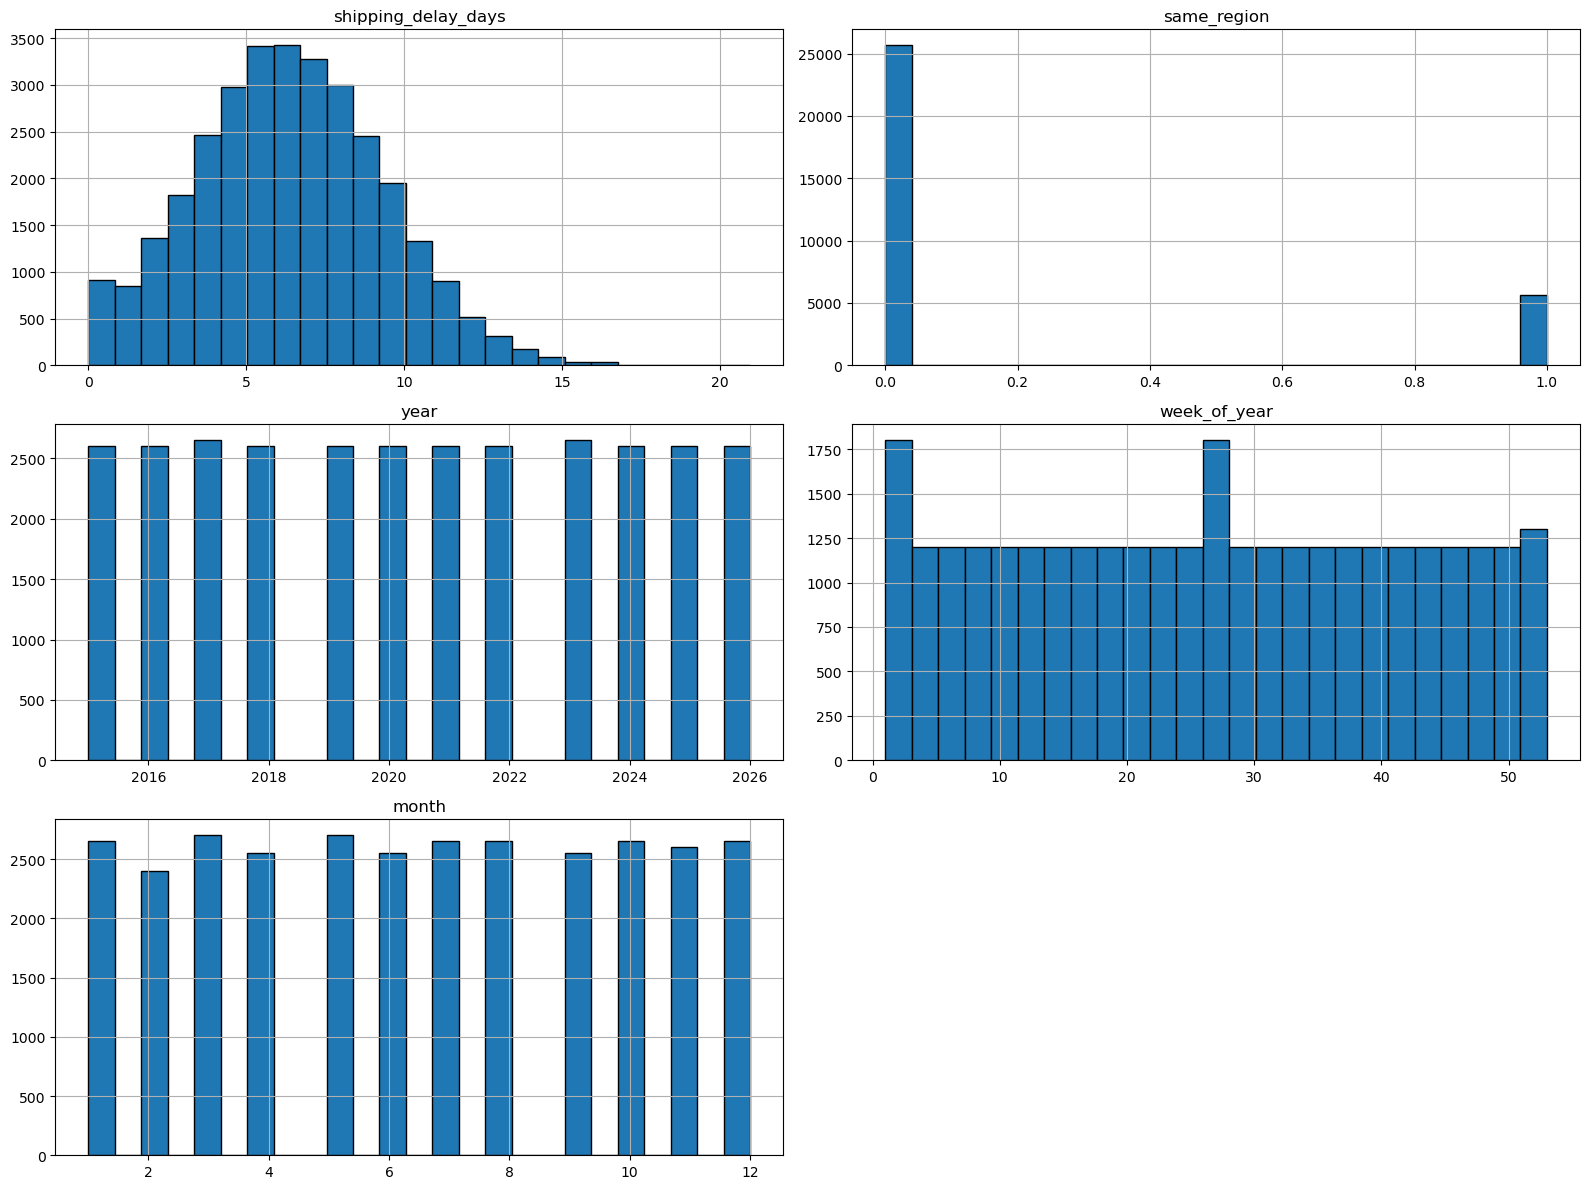

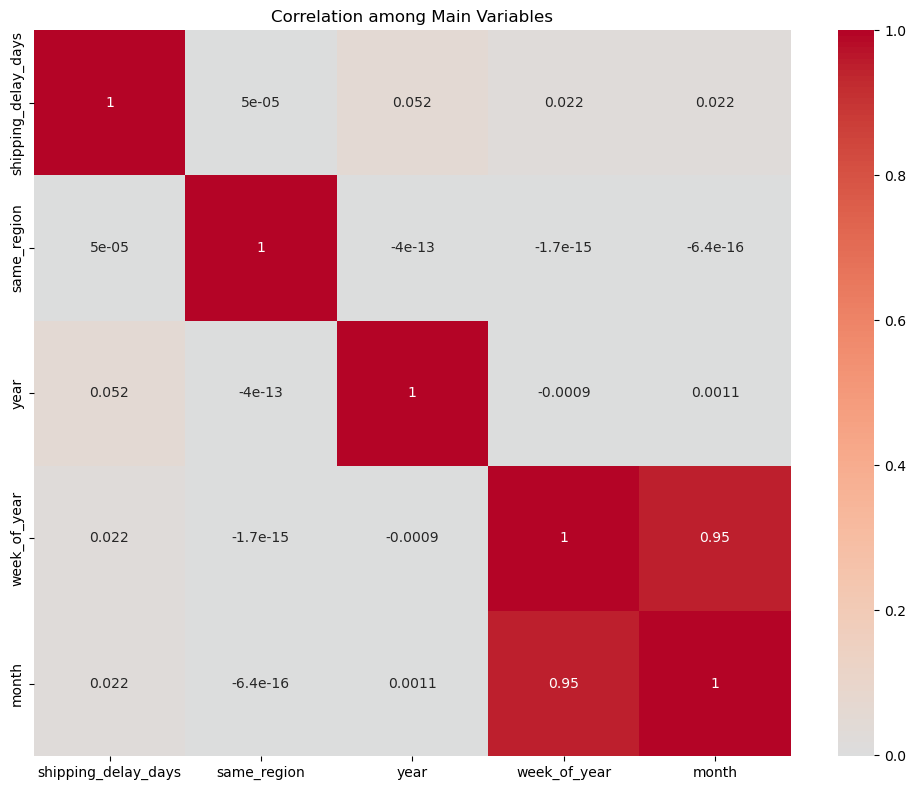

In [16]:

# ---------------------------------------------------------
# 2) Visualize key variables in the dataset
# ---------------------------------------------------------
main_vars = [
    c for c in df.columns
    if c in {
        "shipping_delay_days", "route_distance_km", "population", "gdp_per_capita",
        "trade_dependency_score", "port_capacity_index", "logistics_performance_index",
        "active_events", "new_events", "max_severity", "mean_severity",
        "total_risk_increase", "same_region", "year", "month", "week_of_year"
    }
]

# Histograms for main numeric variables
df[main_vars].hist(figsize=(16, 12), bins=25, edgecolor="black")
plt.tight_layout()
plt.show()

# Correlation heatmap
corr = df[main_vars].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation among Main Variables")
plt.tight_layout()
plt.show()